# API Client Example

This notebook demonstrates how to download one campaign with `api.client`, persist the sensor CSV payloads under `data/campaigns/`, inspect the canonical `metadata.csv`, and plot the stored spectra.

**System boundary**
- Domain/boundary: `api.client` owns HTTP pagination, TLS settings, payload normalization, `metadata.csv` materialization, and sensor CSV persistence.
- Application/orchestration: this notebook selects a campaign, triggers the download, inspects the saved metadata, reloads the saved sensor CSV files, and renders figures.
- Side effects: HTTPS requests to the remote API, CSV writes under `data/`, and notebook plots.
- Pattern choice: the notebook stays thin so the boundary behavior remains testable outside Jupyter.


In [13]:
from __future__ import annotations

import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the notebook launch directory."""

    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "measurement_calibration").exists() and (
            candidate / "data"
        ).exists():
            return candidate
    raise RuntimeError(
        "Could not locate the repository root from the current notebook session"
    )


def validate_row_indices(
    n_records: int,  # Number of rows available in every loaded sensor CSV
    requested_indices: tuple[int, ...],  # Record indices requested for plotting
) -> tuple[int, ...]:  # Valid row indices in the original requested order
    """Keep only row indices that are valid for every loaded sensor CSV."""

    valid_indices = tuple(
        index for index in requested_indices if 0 <= index < n_records
    )
    if not valid_indices:
        raise ValueError("No requested row indices exist in the downloaded data")
    return valid_indices


def build_frequency_axis_mhz(
    start_freq_hz: float,  # Lower band edge from one stored measurement [Hz]
    end_freq_hz: float,  # Upper band edge from one stored measurement [Hz]
    n_bins: int,  # Number of PSD bins in the stored measurement
) -> np.ndarray:  # Frequency axis in MHz aligned with the PSD vector
    """Build an evenly spaced plotting axis for one PSD vector."""

    if n_bins <= 0:
        raise ValueError("n_bins must be positive")
    return np.linspace(start_freq_hz / 1.0e6, end_freq_hz / 1.0e6, n_bins)


def select_representative_row_indices(
    n_records: int,  # Number of aligned measurements available across sensors
) -> tuple[int, ...]:  # First, midpoint, and last indices without duplicates
    """Select representative record indices for campaign overlay plots."""

    if n_records <= 0:
        raise ValueError("n_records must be positive")

    ordered_indices: list[int] = []
    for index in (0, n_records // 2, n_records - 1):
        if index not in ordered_indices:
            ordered_indices.append(index)
    return tuple(ordered_indices)


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import api.client as client

client = importlib.reload(client)
pd.options.display.max_colwidth = 120


## Configure The Download

Choose any campaign label/id pair. The client already knows the full `Node1..Node10` network and adapts dynamically when a campaign is only available for a subset of sensors.


In [14]:
campaign_label = "LNA16_VGA32"
campaign_id = 211
sensor_mac_by_label = client.SENSOR_NETWORK_MAC_BY_LABEL
output_root = REPO_ROOT / client.CAMPAIGNS_DATA_DIR

# The deployed API currently requires verify_tls=False in this environment.
api_client = client.MeasurementApiClient(
    client.MeasurementApiConfig(verify_tls=False, timeout_s=30.0, page_size=5000)
)

display(
    pd.DataFrame(
        [
            {
                "campaign_label": campaign_label,
                "campaign_id": campaign_id,
                "output_root": str(output_root.relative_to(REPO_ROOT)),
                "n_sensors": len(sensor_mac_by_label),
            }
        ]
    )
)
display(
    pd.DataFrame(
        [
            {"sensor_label": sensor_label, "mac": mac_address}
            for sensor_label, mac_address in sensor_mac_by_label.items()
        ]
    ).sort_values("sensor_label")
)


,campaign_label,campaign_id,output_root,n_sensors
0,LNA16_VGA32,211,data/campaigns,10


,sensor_label,mac
0,Node1,d8:3a:dd:f7:1d:f2
9,Node10,d8:3a:dd:f7:1d:90
1,Node2,d8:3a:dd:f4:4e:26
2,Node3,d8:3a:dd:f7:22:87
3,Node4,d8:3a:dd:f6:fc:be
4,Node5,d8:3a:dd:f7:21:52
5,Node6,d8:3a:dd:f7:1a:cc
6,Node7,d8:3a:dd:f7:1d:b6
7,Node8,d8:3a:dd:f7:1b:20
8,Node9,d8:3a:dd:f4:4e:d1


## Download And Persist CSV Files

This cell creates `data/campaigns/<campaign>/`, writes one canonical `metadata.csv`, and writes one measurement CSV per retained sensor using the repository's acquisition schema. The metadata file intentionally keeps one column name per physical quantity and omits `antenna`, because that field does not affect this calibration workflow. Sensors that are unavailable for the selected campaign are reported explicitly instead of aborting the full request.


In [15]:
download_result = api_client.download_campaign_csvs(
    campaign_label=campaign_label,
    campaign_id=campaign_id,
    output_root=output_root,
    drop_missing_pxx=True,
    skip_missing_sensors=True,
)
stored_paths = download_result.saved_csv_paths
metadata_path = download_result.metadata_csv_path

if not stored_paths:
    raise ValueError("No sensor CSVs were materialized for the selected campaign")
if metadata_path is None:
    raise ValueError("The client did not materialize metadata.csv for the selected campaign")

metadata_frame = pd.read_csv(metadata_path)

display(
    pd.DataFrame(
        [
            {
                "metadata_csv_path": str(metadata_path.relative_to(REPO_ROOT)),
                "n_metadata_columns": int(metadata_frame.shape[1]),
                "n_sensor_csvs": len(stored_paths),
            }
        ]
    )
)
display(metadata_frame)

display(
    pd.DataFrame(
        [
            {
                "sensor_label": sensor_label,
                "csv_path": str(csv_path.relative_to(REPO_ROOT)),
            }
            for sensor_label, csv_path in stored_paths.items()
        ]
    ).sort_values("sensor_label")
)

if download_result.skipped_sensors:
    display(
        pd.DataFrame(
            [
                {
                    "sensor_label": sensor_label,
                    "reason": reason,
                }
                for sensor_label, reason in download_result.skipped_sensors.items()
            ]
        ).sort_values("sensor_label")
    )


,metadata_csv_path,n_metadata_columns,n_sensor_csvs
0,data/campaigns/LNA16_VGA32/metadata.csv,14,6


,campaign_label,campaign_id,start_date,stop_date,start_time,stop_time,acquisition_freq_minutes,central_freq_MHz,span_MHz,sample_rate_hz,lna_gain_dB,vga_gain_dB,rbw_kHz,antenna_amp
0,LNA16_VGA32,211,2026-03-11T00:00:00.000Z,2026-03-11T00:00:00.000Z,13:00:00,14:00:00,2,98,20,20000000,16,32,3,True


,sensor_label,csv_path
0,Node1,data/campaigns/LNA16_VGA32/Node1.csv
5,Node10,data/campaigns/LNA16_VGA32/Node10.csv
1,Node2,data/campaigns/LNA16_VGA32/Node2.csv
2,Node3,data/campaigns/LNA16_VGA32/Node3.csv
3,Node5,data/campaigns/LNA16_VGA32/Node5.csv
4,Node9,data/campaigns/LNA16_VGA32/Node9.csv


,sensor_label,reason
0,Node4,Remote API returned HTTP 404 for campaign_id=211
1,Node6,Remote API returned HTTP 404 for campaign_id=211
2,Node7,Remote API returned HTTP 404 for campaign_id=211
3,Node8,Remote API returned HTTP 404 for campaign_id=211


## Reload The Saved Sensor CSV Files

The client loader parses the JSON-encoded `pxx` column into `numpy` arrays so plotting stays simple. The campaign metadata was already materialized and inspected in the previous step.


In [16]:
frames_by_sensor = client.load_measurement_frames(stored_paths)
summary_rows: list[dict[str, object]] = []

if not frames_by_sensor:
    raise ValueError("The selected campaign produced no saved sensor CSV files")

for sensor_label, frame in frames_by_sensor.items():
    first_row = frame.iloc[0]
    summary_rows.append(
        {
            "sensor_label": sensor_label,
            "records": len(frame),
            "frequency_start_mhz": float(first_row["start_freq_hz"]) / 1.0e6,
            "frequency_end_mhz": float(first_row["end_freq_hz"]) / 1.0e6,
            "n_bins": int(np.asarray(first_row["pxx"]).size),
            "first_timestamp_ms": int(first_row["timestamp"]),
        }
    )
summary_frame = pd.DataFrame(summary_rows).sort_values("sensor_label")
display(summary_frame)


,sensor_label,records,frequency_start_mhz,frequency_end_mhz,n_bins,first_timestamp_ms
0,Node1,30,88.0,108.0,16384,1773234008669
5,Node10,30,88.0,108.0,16384,1773234009360
1,Node2,30,88.0,108.0,16384,1773234008373
2,Node3,30,88.0,108.0,16384,1773234008642
3,Node5,30,88.0,108.0,16384,1773234009363
4,Node9,30,88.0,108.0,16384,1773234009402


## Campaign Analysis

This section summarizes the time span and coarse PSD statistics for each sensor that returned data in the selected campaign.



In [17]:
analysis_rows: list[dict[str, object]] = []

# Reduce each sensor to stable campaign-level descriptors that are easy to compare.
for sensor_label, frame in sorted(frames_by_sensor.items()):
    timestamps_ms = frame["timestamp"].dropna().astype(np.int64)
    pxx_arrays = [np.asarray(pxx, dtype=np.float64) for pxx in frame["pxx"]]
    pxx_lengths = np.asarray([pxx.size for pxx in pxx_arrays], dtype=np.int64)
    mean_band_power_dbm = np.asarray([float(np.mean(pxx)) for pxx in pxx_arrays])
    noise_floor_dbm = np.asarray(
        [float(np.percentile(pxx, 10.0)) for pxx in pxx_arrays],
        dtype=np.float64,
    )

    start_timestamp_ms = int(timestamps_ms.min())
    end_timestamp_ms = int(timestamps_ms.max())
    analysis_rows.append(
        {
            "sensor_label": sensor_label,
            "records": len(frame),
            "timestamp_start_utc": pd.to_datetime(
                start_timestamp_ms,
                unit="ms",
                utc=True,
            ),
            "timestamp_end_utc": pd.to_datetime(
                end_timestamp_ms,
                unit="ms",
                utc=True,
            ),
            "time_span_min": (end_timestamp_ms - start_timestamp_ms) / 60_000.0,
            "median_n_bins": int(np.median(pxx_lengths)),
            "mean_band_power_dbm": float(np.mean(mean_band_power_dbm)),
            "mean_noise_floor_dbm": float(np.mean(noise_floor_dbm)),
        }
    )

campaign_analysis_frame = pd.DataFrame(analysis_rows).sort_values("sensor_label")
display(campaign_analysis_frame)


,sensor_label,records,timestamp_start_utc,timestamp_end_utc,time_span_min,median_n_bins,mean_band_power_dbm,mean_noise_floor_dbm
0,Node1,30,2026-03-11 13:00:08.669000+00:00,2026-03-11 13:58:08.620000+00:00,57.999183,16384,-30.876942,-39.073043
1,Node10,30,2026-03-11 13:00:09.360000+00:00,2026-03-11 13:58:09.834000+00:00,58.007900,16384,-50.406243,-55.182954
2,Node2,30,2026-03-11 13:00:08.373000+00:00,2026-03-11 13:58:08.573000+00:00,58.003333,16384,-33.860937,-40.448726
3,Node3,30,2026-03-11 13:00:08.642000+00:00,2026-03-11 13:58:09.196000+00:00,58.009233,16384,-23.398673,-29.212146
4,Node5,30,2026-03-11 13:00:09.363000+00:00,2026-03-11 13:58:09.522000+00:00,58.002650,16384,-33.264786,-40.766802
5,Node9,30,2026-03-11 13:00:09.402000+00:00,2026-03-11 13:58:09.428000+00:00,58.000433,16384,-28.821484,-34.718486


## Plot Stored Spectra

The figure overlays the same record index across all saved sensor CSV files. If a requested row index does not exist for every sensor, it is skipped explicitly.


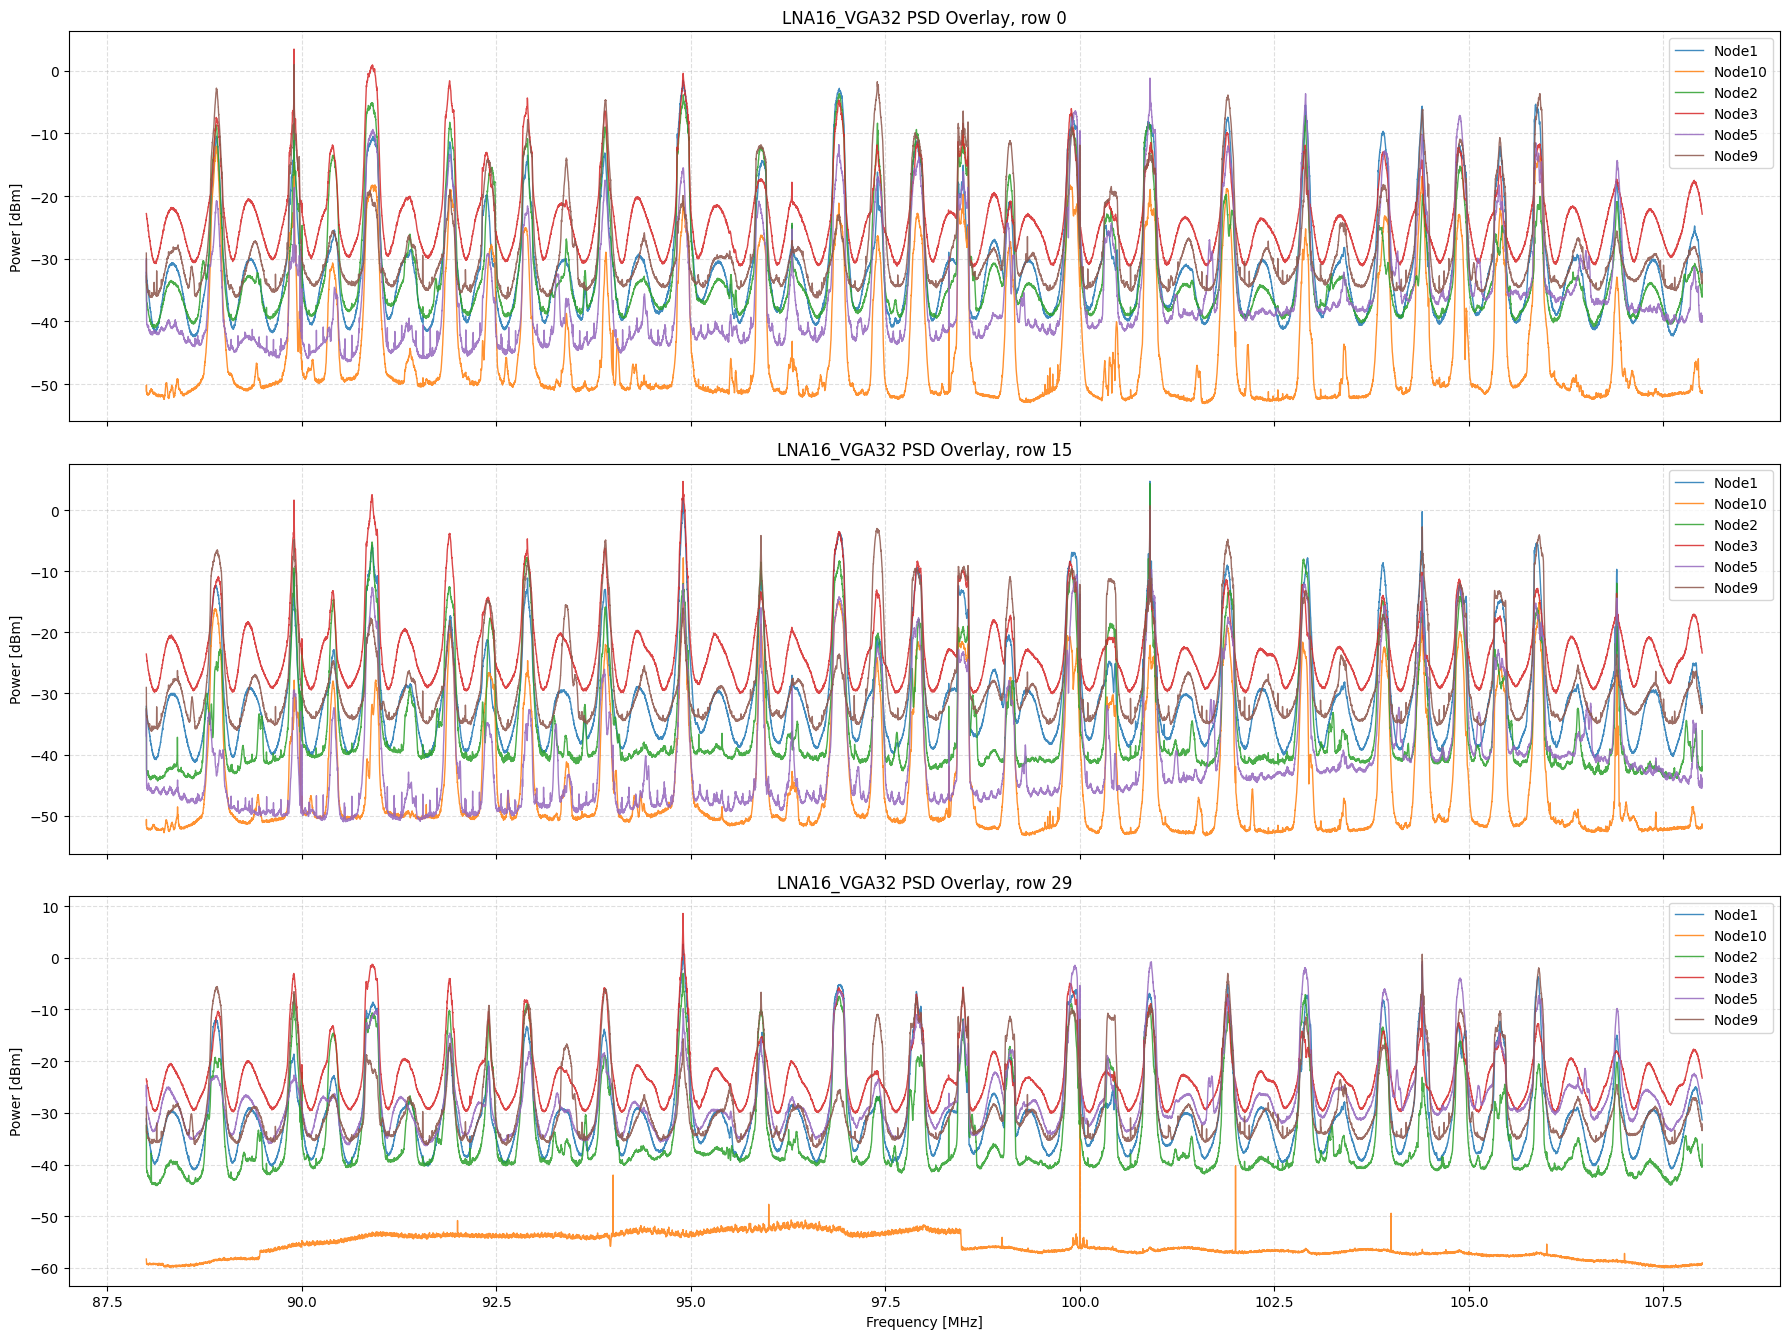

In [18]:
min_records = min(len(frame) for frame in frames_by_sensor.values())
row_indices = validate_row_indices(
    min_records,
    select_representative_row_indices(min_records),
)

fig, axes = plt.subplots(
    nrows=len(row_indices),
    ncols=1,
    figsize=(18, 4.5 * len(row_indices)),
    sharex=True,
)
if len(row_indices) == 1:
    axes = [axes]

for ax, row_index in zip(axes, row_indices):
    for sensor_label, frame in sorted(frames_by_sensor.items()):
        row = frame.iloc[row_index]
        pxx_db = np.asarray(row["pxx"], dtype=np.float64)

        # Each stored row carries its own band edges, so build the plotting
        # axis from the persisted metadata instead of assuming a fixed band.
        frequency_mhz = build_frequency_axis_mhz(
            start_freq_hz=float(row["start_freq_hz"]),
            end_freq_hz=float(row["end_freq_hz"]),
            n_bins=pxx_db.size,
        )
        ax.plot(frequency_mhz, pxx_db, label=sensor_label, linewidth=1.0, alpha=0.85)

    ax.set_title(f"{campaign_label} PSD Overlay, row {row_index}")
    ax.set_ylabel("Power [dBm]")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="best")

axes[-1].set_xlabel("Frequency [MHz]")
plt.tight_layout()
plt.show()
